# University Rankings | Exploratory Data Analysis

## Project Overview


This project explores a dataset of 1,000 universities ranked worldwide for the 2018–2019 academic year.

The analysis focuses on understanding the geographic distribution of universities and examining how different academic and research-related indicators relate to global university rankings.

The project includes data inspection, data cleaning, exploratory analysis, and data visualization to identify patterns in university performance across countries and ranking indicators.

## Project Objective

The main objectives of this analysis are to:

- Examine the structure and quality of the university rankings dataset.
- Identify the countries with the largest number of ranked universities.
- Explore the relationship between global ranking and research-related indicators.
- Analyze the distribution of citations and research influence across institutions.
- Compare alumni employment rankings across countries and institutions.
- Identify notable patterns and limitations within the dataset.

## Dataset Overview


The dataset contains information on the top 1,000 universities worldwide for the 2018–2019 academic year.

Each row represents one university, while the columns contain its global ranking, national ranking, academic performance indicators, research-related indicators, and overall score.

The dataset contains:

- **1,000 universities**
- **12 variables**
- **61 countries/locations**

The dataset is primarily cross-sectional and represents university rankings for a single academic year.

### Feature Description


| Feature | Description |
|---|---|
| World Rank | Global ranking position of the university. |
| Institution | Name of the university or higher education institution. |
| Location | Country in which the institution is located. |
| National Rank | Ranking position of the institution within its country. |
| Quality of Education | Ranking indicator related to education quality. |
| Alumni Employment | Ranking indicator related to alumni employment outcomes. |
| Quality of Faculty | Ranking indicator related to faculty quality. |
| Research Output | Ranking indicator related to research output. |
| Quality Publications | Ranking indicator related to publication quality. |
| Influence | Ranking indicator related to academic/research influence. |
| Citations | Ranking indicator related to research citations. |
| Score | Overall university score. |

## Tools & Libraries



- Python
- Pandas
- NumPy
- Matplotlib
- Plotly

## Workflow


1. Import libraries and load the dataset
2. Inspect the dataset structure
3. Check data types and descriptive statistics
4. Identify missing values and placeholder values
5. Check duplicate records
6. Clean column names and text fields
7. Handle non-numeric ranking placeholders
8. Correct data types and inconsistent values
9. Explore geographic distribution
10. Analyze ranking-related indicators
11. Explore alumni employment rankings
12. Summarize key findings and limitations

In [37]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import unicodedata

In [38]:
#Import Data 

Data = pd.read_csv("../data/eighteen_nineteen_university_datasets.csv", encoding = 'unicode-escape')

#DataFrame

df = pd.DataFrame(Data)

### Dataset Information

In [39]:
Data.head(5)

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2


### Initial Dataset Inspection


The dataset was first inspected to understand its dimensions, structure, data types, and basic descriptive statistics.

In [40]:
#number_of_rows&columns

rows, columns =df.shape
print(f"Number of Rows are : {rows}",'\n',f"Number of columns are : {columns}")

Number of Rows are : 1000 
 Number of columns are : 12


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   int64  
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   int64  
 4   Quality of Education  1000 non-null   object 
 5   Alumni Employment     1000 non-null   object 
 6   Quality of Faculty    1000 non-null   object 
 7   Research Output       1000 non-null   object 
 8   Quality Publications  1000 non-null   object 
 9   Influence             1000 non-null   object 
 10  Citations             1000 non-null   object 
 11  Score                 1000 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 93.9+ KB


In [42]:
#Describe_Dataset

df.describe()

,World Rank,National Rank,Score
count,1000.000000,1000.00000,1000.000000
mean,500.500000,40.02300,75.034300
std,288.819436,49.22871,4.670858
min,1.000000,1.00000,69.800000
25%,250.750000,6.00000,71.500000
50%,500.500000,21.00000,73.750000
75%,750.250000,51.00000,77.300000
max,1000.000000,213.00000,100.000000


In [43]:
#Column_Detail

def col_detail (df1):
    col_name = []
    dtypes = []
    count = []
    unique = []
    for col in df1.columns:
        col_name.append(col)
        dtypes.append(df1[col].dtype)
        count.append(len(df1[col]))
        unique.append(len(df1[col].unique()))
        
    output = pd.DataFrame({
        'Column_name' : col_name,
        'Dtype' : dtypes,
        'Count' : count,
        'Unique': unique
    })
    return output

col_detail(df)

,Column_name,Dtype,Count,Unique
0,World Rank,int64,1000,1000
1,Institution,object,1000,1000
2,Location,object,1000,61
3,National Rank,int64,1000,213
4,Quality of Education,object,1000,404
5,Alumni Employment,object,1000,492
6,Quality of Faculty,object,1000,221
7,Research Output,object,1000,905
8,Quality Publications,object,1000,892
9,Influence,object,1000,830


## Data Cleaning

### Missing Values

In [44]:
#missing_values_each_col

print("Number of missing values in each column :" , "\n ")
print(df.isna().sum())

#number_of_missing_values
num_of_missing_value= df.isna().sum().sum()

print(f"number of missing values : {num_of_missing_value}")

Number of missing values in each column : 
 
World Rank              0
Institution             0
Location                0
National Rank           0
Quality of Education    0
Alumni Employment       0
Quality of Faculty      0
Research Output         0
Quality Publications    0
Influence               0
Citations               0
Score                   0
dtype: int64
number of missing values : 0



The initial missing value check returned no standard `NaN` values. However, further inspection revealed that missing information is represented by the placeholder `-` in several ranking-related columns.

These placeholders occur mainly in `Quality_of_Education` and `Quality_of_Faculty`, indicating that a substantial portion of the values for these variables is unavailable.

### Duplicate Records

In [45]:
#Number_of_Duplicate_Records

num_dup = df.duplicated().sum()

if num_dup ==0 :
    print("There are no duplicate records in this dataset.")
else:
    print(f"There are {num_dup} duplicated records in this dataset.")

There are no duplicate records in this dataset.


### Remove Space

In [46]:
df.columns

Index(['World Rank', 'Institution', 'Location', 'National Rank',
       'Quality of Education', 'Alumni Employment', 'Quality of Faculty',
       'Research Output', 'Quality Publications', 'Influence', 'Citations',
       'Score'],
      dtype='object')

In [47]:
#Remove_space_column_names

df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['World_Rank', 'Institution', 'Location', 'National_Rank',
       'Quality of_Education', 'Alumni_Employment', 'Quality of_Faculty',
       'Research_Output', 'Quality_Publications', 'Influence', 'Citations',
       'Score'],
      dtype='object')

### Hidden Characters

In [48]:
#Hidden_Charachters

for col in df.columns:
    print(repr(col))

'World_Rank'
'Institution'
'Location'
'National_Rank'
'Quality\xa0of_Education'
'Alumni_Employment'
'Quality\xa0of_Faculty'
'Research_Output'
'Quality_Publications'
'Influence'
'Citations'
'Score'


In [49]:
#Remove_hidden_charachter

df.columns = df.columns.str.replace(r"\s+", "_", regex=True).str.strip()

In [50]:
# Validate
df.columns

Index(['World_Rank', 'Institution', 'Location', 'National_Rank',
       'Quality_of_Education', 'Alumni_Employment', 'Quality_of_Faculty',
       'Research_Output', 'Quality_Publications', 'Influence', 'Citations',
       'Score'],
      dtype='object')

In [51]:
df["Institution"].unique()

array(['Harvard University', 'Stanford University',
       'Massachusetts Institute of Technology', 'University of Cambridge',
       'University of Oxford', 'University of California, Berkeley',
       'Princeton University', 'Columbia University',
       'California Institute of Technology', 'University of Chicago',
       'Yale University', 'University of Tokyo',
       'University of Pennsylvania', 'Cornell University',
       'University of California, Los Angeles',
       'Johns Hopkins University', 'University of Toronto',
       'University of Michigan, Ann Arbor',
       'University of Washington - Seattle',
       'University of California, San Diego', 'University College London',
       'University of California, San Francisco',
       'Northwestern University', 'Duke University',
       'New York University', 'Kyoto University',
       'University of Wisconsin\x96Madison', 'ETH Zurich',
       'Sorbonne University', 'Imperial College London',
       'University of Texas at 

In [52]:
#Hidden_charachters
df['Institution'] = df['Institution'].str.replace('\x96', '-', regex=False)

### Remove accents

In [53]:

def remove_accents_ascii(s):
    if isinstance(s, str):
        return unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    return s

df["Location"] = df["Location"].apply(remove_accents_ascii)
df["Institution"] = df["Institution"].apply(remove_accents_ascii)


The function takes a string, splits letters from their accent marks, then removes those accent marks and returns the clean version.

In [54]:
# Validate

df["Location"].unique()

array(['USA', 'United Kingdom', 'Japan', 'Canada', 'Switzerland',
       'France', 'Denmark', 'Israel', 'Germany', 'Sweden', 'Australia',
       'South Korea', 'Italy', 'Netherlands', 'Norway', 'Brazil', 'Spain',
       'China', 'Finland', 'Singapore', 'Belgium', 'Taiwan', 'Russia',
       'Hong Kong', 'Austria', 'Czech Republic', 'Portugal',
       'South Africa', 'Ireland', 'New Zealand', 'Mexico', 'Poland',
       'Argentina', 'Greece', 'Saudi Arabia', 'Chile', 'Serbia',
       'Slovenia', 'Iran', 'Hungary', 'India', 'Malaysia', 'Egypt',
       'Croatia', 'Thailand', 'Iceland', 'Estonia', 'Turkey',
       'Slovak Republic', 'Uruguay', 'Lithuania', 'Colombia', 'Uganda',
       'Lebanon', 'Pakistan', 'Romania', 'Bulgaria', 'Cyprus', 'Tunisia',
       'Nigeria', 'Macau'], dtype=object)

### Potential Outliers

In [55]:
#Columns_contain_>1000

cols_with_1000 = [col for col in df.columns if (df[col] == "> 1000").any()]
print(cols_with_1000)

['Alumni_Employment', 'Research_Output', 'Quality_Publications', 'Influence', 'Citations']


In [56]:
for col in cols_with_1000:
    df[col] = df[col].replace("> 1000", 1001)

In [57]:
#Check_for_-

count_per_column = (df == '-').sum()
print(count_per_column)
total_dash = (df == '-').sum().sum()
print(total_dash)

World_Rank                0
Institution               0
Location                  0
National_Rank             0
Quality_of_Education    597
Alumni_Employment         0
Quality_of_Faculty      731
Research_Output           0
Quality_Publications      0
Influence                 0
Citations                 0
Score                     0
dtype: int64
1328


The columns `Quality of Education` and `Quality of Faculty` contain approximately 50% or more missing data; therefore, this should be taken into consideration in subsequent analyses.

In [58]:
df.replace('-', '1001', inplace=True)

Instead of - values, we can replace them with 1001, so that we don’t face issues when plotting the data, and later on when creating models (Given our dataset, we’ll use 1001 to indicate that the value is not meaningful).

### Data Types

In [59]:
#Change_Data_Type

df["Location"] = df["Location"].astype("string")

df["Institution"]=df["Institution"].astype("string")

In [60]:
#Change_Data_type

obj_columns = ['Alumni_Employment','Research_Output','Quality_Publications','Influence','Citations'] 

for col in obj_columns:
    df[col] = df[col].astype(int)

### Inconsistent Institution Name

In [61]:
print(df.iloc[997])

World_Rank                           998
Institution             K?chi University
Location                           Japan
National_Rank                         56
Quality_of_Education                1001
Alumni_Employment                   1001
Quality_of_Faculty                  1001
Research_Output                     1001
Quality_Publications                1001
Influence                            811
Citations                            673
Score                               69.8
Name: 997, dtype: object


In [62]:
#Correct_Value

df.loc[df['Institution'] == 'K?chi University', 'Institution'] = 'Kochi University'

In [63]:
# Validate

df.iloc[997]

World_Rank                           998
Institution             Kochi University
Location                           Japan
National_Rank                         56
Quality_of_Education                1001
Alumni_Employment                   1001
Quality_of_Faculty                  1001
Research_Output                     1001
Quality_Publications                1001
Influence                            811
Citations                            673
Score                               69.8
Name: 997, dtype: object

One institution name contained an encoding related character issue (`K?chi University`). The value was corrected to `Kochi University`.

### Data Visualization

In [64]:
df["Location"].value_counts()

Location
USA                213
China              108
United Kingdom      62
France              58
Japan               56
                  ... 
Uruguay              1
Slovak Republic      1
Estonia              1
Iceland              1
Macau                1
Name: count, Length: 61, dtype: Int64

#### Distribution of Institutions by Location

In [65]:

#Location_Count
location_counts = df['Location'].value_counts().reset_index()
location_counts.columns = ['Country', 'Count']

#Top_10_Locations
top10 = location_counts.head(10)

#Others
others_count = location_counts['Count'][10:].sum()
others_df = pd.DataFrame({'Country': ['Others'], 'Count': [others_count]})

top10_plus_others = pd.concat([top10, others_df], ignore_index=True)

#Colours
Colours = ['#08306b', '#08519c', '#2171b5', '#4292c6', '#6baed6',
          '#9ecae1', '#c6dbef', '#deebf7', '#f7fbff', '#bdbdbd', '#969696']

#Pie_Plot
fig = px.pie(top10_plus_others, 
        names='Country', 
        values='Count', 
        title='Distribution of Institutions by Location (Top 10 + Others)',
        color = 'Count',
        color_discrete_sequence=Colours,
        hole=0.3) 

fig.update_traces(textinfo='percent+label') 

fig.show()

#### Top 20 Locations by Number of Universities

In [66]:
location_counts_20 = df['Location'].value_counts().head(20).reset_index()
location_counts_20.columns = ['Location', 'Universities']

#Bar_h
fig = px.bar(
    location_counts_20,
    x='Universities',
    y='Location',
    orientation='h',
    text='Universities',
    color='Universities',
    color_continuous_scale='Blues'
)

fig.update_traces(textposition='outside', textfont_size=10)
fig.update_layout(
    title='Top 20 Locations by Number of Universities',
    xaxis_title='Number of universities',
    yaxis_title='Location',
    yaxis=dict(autorange='reversed'))

fig.show()

The USA has the highest number of universities in our dataset, totaling 213 institutions, which corresponds to 21.3% of the overall 1,000 universities. China follows with 108 universities, accounting for 10.8% of the dataset.

#### Number of Institution per Country: A World Map Visualization

In [67]:
#WorldMap

country_counts = df['Location'].value_counts().reset_index()
country_counts.columns = ['Country','Institution_Count']

fig = px.choropleth(country_counts,locations='Country',
            locationmode='country names',
            color = 'Institution_Count',
            color_continuous_scale='Plasma',
            title="Number of Institutions per country",
            width = 1000,
            height= 700)
    
fig.show()

/var/folders/q6/dccp8f8s51z027wzlhx2fmsw0000gn/T/ipykernel_24757/1658461507.py:6: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



The geographic distribution shows that universities in the dataset are concentrated in a limited number of countries, with the United States, China, and several European and Asian countries accounting for a large share of the institutions.

#### Relationship Between Ranking Indicators and World Rank

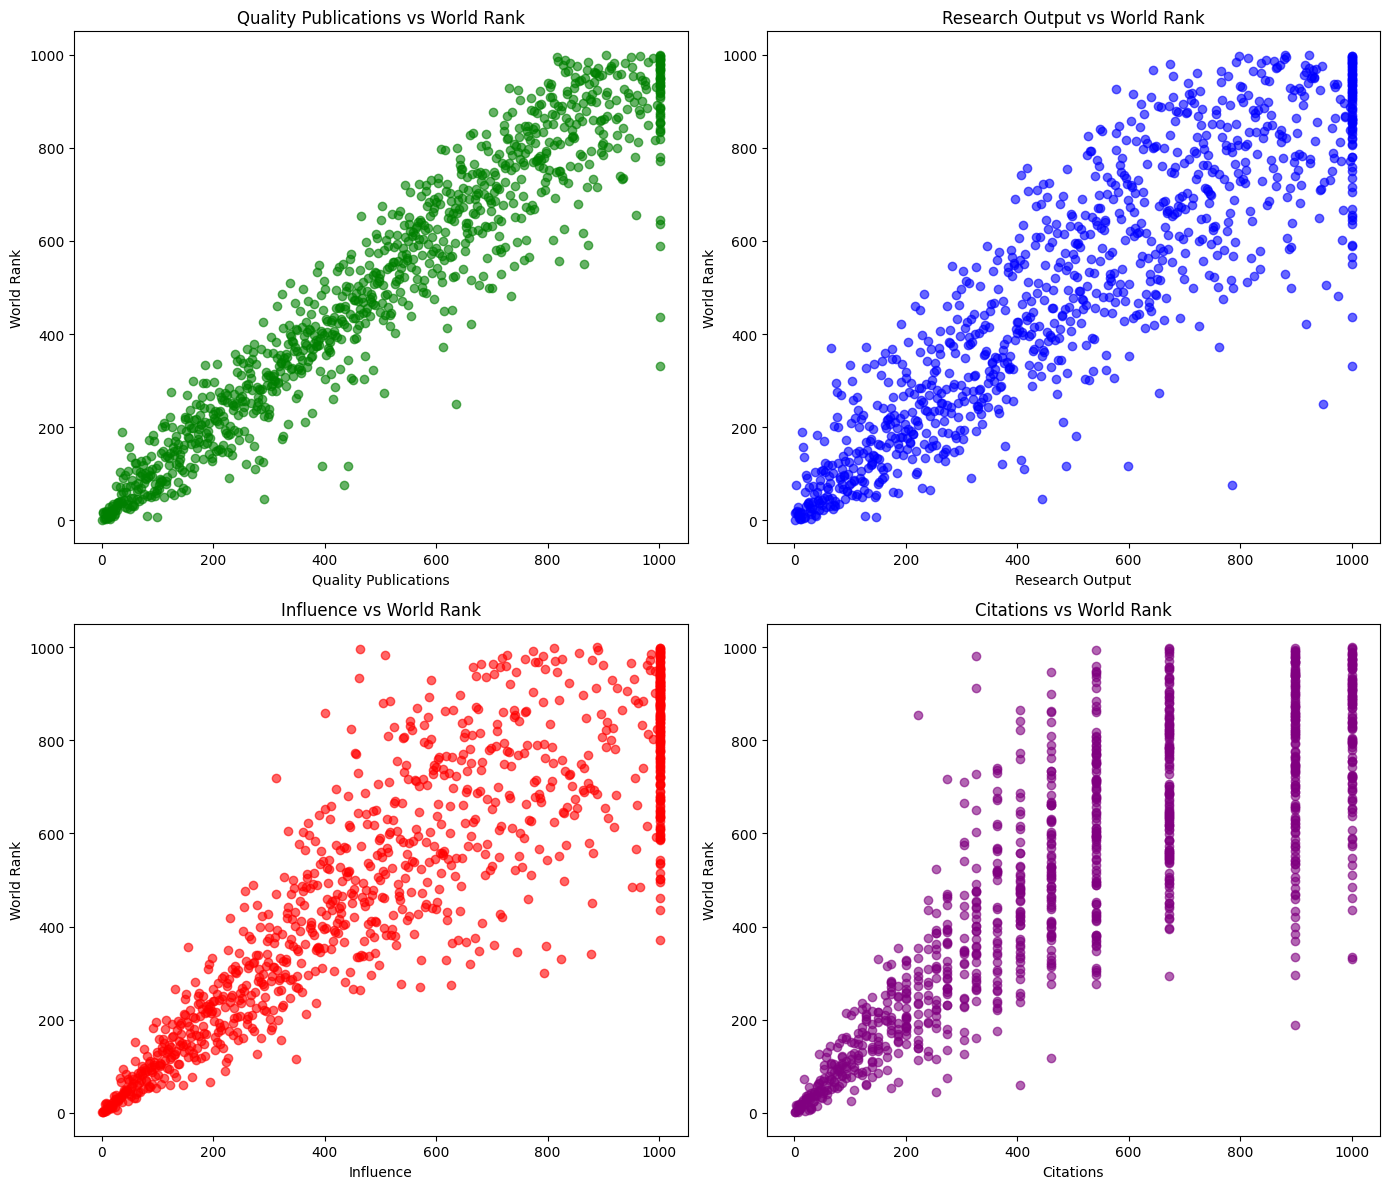

In [68]:
#Subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Subplot 1: Quality_Publications vs World_Rank
axes[0, 0].scatter(df["Quality_Publications"], df["World_Rank"], color='green', alpha=0.6)
axes[0, 0].set_xlabel("Quality Publications")
axes[0, 0].set_ylabel("World Rank")
axes[0, 0].set_title("Quality Publications vs World Rank")

# Subplot 2: Research_Output vs World_Rank
axes[0, 1].scatter(df["Research_Output"], df["World_Rank"], color='blue', alpha=0.6)
axes[0, 1].set_xlabel("Research Output")
axes[0, 1].set_ylabel("World Rank")
axes[0, 1].set_title("Research Output vs World Rank")

# Subplot 3: Influence vs World_Rank
axes[1, 0].scatter(df["Influence"], df["World_Rank"], color='red', alpha=0.6)
axes[1, 0].set_xlabel("Influence")
axes[1, 0].set_ylabel("World Rank")
axes[1, 0].set_title("Influence vs World Rank")

# Subplot 4: Citations vs World_Rank
axes[1, 1].scatter(df["Citations"], df["World_Rank"], color='purple', alpha=0.6)
axes[1, 1].set_xlabel("Citations")
axes[1, 1].set_ylabel("World Rank")
axes[1, 1].set_title("Citations vs World Rank")


plt.tight_layout() 
plt.show()



- Higher-quality publications tend to be associated with better global rankings, although the relationship is not perfectly consistent.


- Research output shows a similar pattern, with stronger-performing institutions generally appearing toward the higher end of the ranking.


- Influence and citations also show visible differences across ranking positions, but substantial variation remains among institutions.


- These plots show associations rather than causal relationships and do not establish that any single indicator determines a university's global rank.

#### Distribution of Citations and Influence

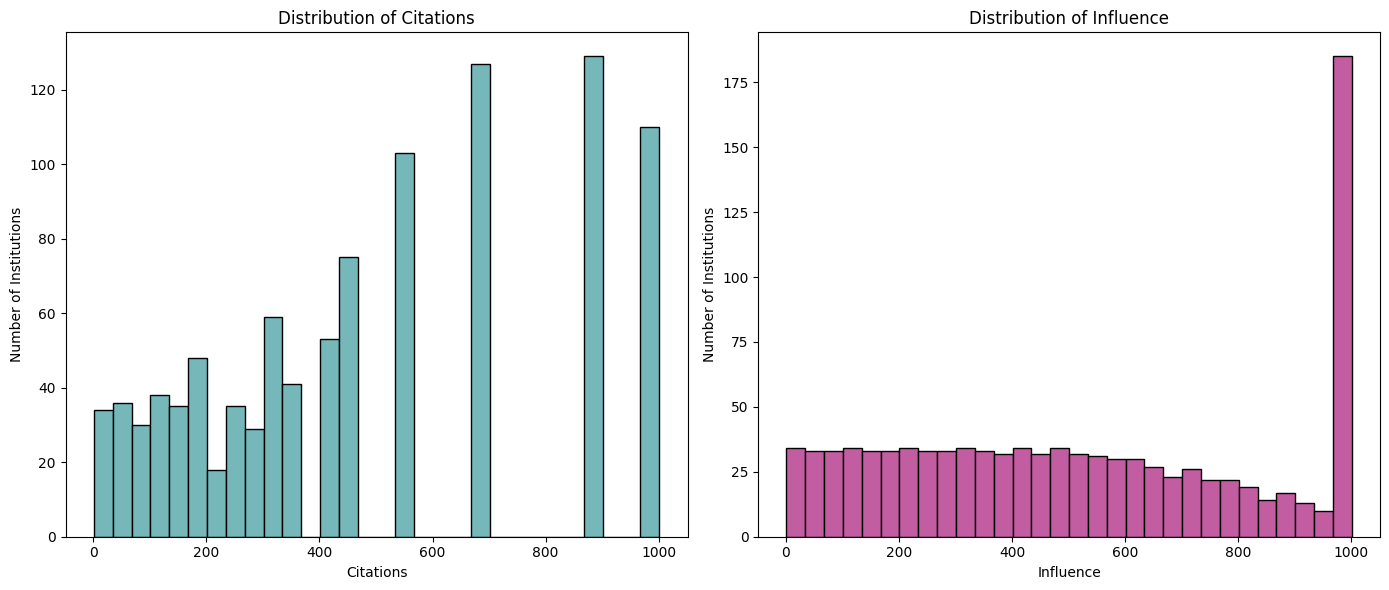

In [69]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for Citations
axes[0].hist(df["Citations"], bins=30, color="#76b7ba", edgecolor='black')
axes[0].set_xlabel("Citations")
axes[0].set_ylabel("Number of Institutions")
axes[0].set_title("Distribution of Citations")

# Histogram for Influence
axes[1].hist(df["Influence"], bins=30, color="#c35da1", edgecolor='black')
axes[1].set_xlabel("Influence")
axes[1].set_ylabel("Number of Institutions")
axes[1].set_title("Distribution of Influence")

plt.tight_layout()  
plt.show()


#### Average of Alumni Employment by Location

In [70]:
#groupby_location
#alumni_mean

alumni_by_location = df.groupby('Location')['Alumni_Employment'].mean().reset_index()

#Top_20_loc

alumni_by_location = alumni_by_location.sort_values(by='Alumni_Employment').head(20)

#hbar_Plot
fig = px.bar(alumni_by_location, 
        x='Alumni_Employment', 
        y='Location',
        orientation='h',
        title='Average of Alumni Employment by Location',
        color='Alumni_Employment',
        color_continuous_scale='Greens')

fig.update_layout(
    height=800, 
    yaxis=dict(
        tickfont=dict(size=10) )
)

fig.show()



In [71]:
df_lebanon = df[df["Location"]=="Lebanon"]
df_lebanon

,World_Rank,Institution,Location,National_Rank,Quality_of_Education,Alumni_Employment,Quality_of_Faculty,Research_Output,Quality_Publications,Influence,Citations,Score
782,783,American University of Beirut,Lebanon,1,202,176,1001,899,862,698,673,71.2


Lebanon shows the best average rank in Alumni Employment among all locations. However, this result is based on only one institution within the top 1000 universities, namely the American University of Beirut. Although the Alumni Employment value for this university is 176, the outcome appears significant because averages were calculated across institutions for each location. Since Lebanon has only one data point, this finding is not particularly meaningful or representative.

In [72]:

Top_20_alumni = df.nsmallest(20, 'Alumni_Employment')

fig = px.bar(Top_20_alumni,
             x='Alumni_Employment',
             y='Institution',
             orientation='h',
             title='Top 20 Institutions with best Alumni Employment',
             color='Location',
             text = 'Location',
             color_discrete_sequence=px.colors.qualitative.T10)

fig.update_traces(textposition='outside')  
fig.update_layout(
    height=800,
    yaxis=dict(tickfont=dict(size=10))
)

fig.show()


As observed in the chart above, the highest rank in the Alumni Employment metric belongs to __Harvard University__ in the USA. 

Among the top 20 institutions in this metric, 8 are located in the __USA__, 5 in __France__, and 3 in __Japan__.

 This distribution highlights the concentration of high performing universities in specific countries, reflecting regional strengths in graduate employability.


## Key Findings


- The United States has the largest number of universities represented in the dataset, followed by China and the United Kingdom.


- The geographic distribution of the top 1,000 universities is highly concentrated in a relatively small number of countries.


- Research related indicators such as publications, research output, influence, and citations show visible associations with global ranking.


- Alumni employment rankings are concentrated among a number of highly ranked institutions, particularly in the United States, France, and Japan.


- Country level averages can be misleading when based on very small numbers of institutions; therefore, minimum group size criteria should be considered when comparing countries.

## Limitations


- The dataset represents a single academic year (2018–2019), so changes over time cannot be analyzed.


- The analysis is exploratory and identifies associations rather than causal relationships.


- Some ranking indicators contain unavailable values represented by placeholders.


- Country-level comparisons can be sensitive to the number of institutions represented in each country.


- The dataset contains the top 1,000 institutions and therefore does not represent the full global university population.

## Conclusion


This exploratory analysis examined the geographic distribution and performance indicators of the world's top 1,000 universities for the 2018–2019 academic year.

The analysis showed that university representation is concentrated in a relatively small number of countries and that research-related indicators such as publications, research output, influence, and citations display meaningful associations with global ranking.

The analysis also highlighted the importance of considering data quality and sample size when comparing institutions across countries. Overall, the project demonstrates a complete exploratory data analysis workflow, from data inspection and cleaning to visualization and interpretation of findings.